In [11]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt

In [12]:
p = Path("/home/finn/workspace/creatures/logs/simulation_1782586080.log")
assert p.exists()

In [13]:
with open(p, "r") as f:
    lines = f.readlines()

print(len(lines))

9509


In [14]:
def extract_animal_data(line):
    m = re.match(
        r".*animal_despawn,reason=(?P<reason>.*),spawn_at_frame=(?P<spawn_at>.*),despawn_at_frame=(?P<despawn_at>.*),lifetime_frames=(?P<lifetime>.*),genome=(?P<genome>.*),diet=(?P<diet>.*),family=(?P<family>.*).*",
        line,
    )

    if m is not None:
        d = {}
        d["reason"] = m.group("reason")
        d["spawn_at"] = float(m.group("spawn_at"))
        d["despawn_at"] = float(m.group("despawn_at"))
        d["lifetime"] = float(m.group("lifetime"))
        d["genome"] = m.group("genome")
        d["diet"] = m.group("diet")
        d["family"] = int(m.group("family"))
        return d
    return None


In [15]:
df = pd.DataFrame(list(filter(None, map(extract_animal_data, lines))))


In [16]:
df.sort_values("lifetime")

,reason,spawn_at,despawn_at,lifetime,genome,diet,family
16,collision,3963.0,3965.0,2.0,"[-0.059256352, 0.33802894, 0.20602693, 0.98062...",Omnivore,0
1726,collision,25896.0,25898.0,2.0,"[0.7126855, 0.36999065, -0.32748386, -0.316717...",Omnivore,1392114282
1635,collision,25092.0,25094.0,2.0,"[0.023480475, -0.90730006, 0.46750224, -0.7348...",Omnivore,3093977874
1629,collision,24840.0,24842.0,2.0,"[0.017261205, -0.8936973, 0.36019897, -0.73721...",Omnivore,3093977874
1588,collision,23857.0,23859.0,2.0,"[0.013349758, -0.91227007, 0.3739714, -0.71569...",Omnivore,3093977874
...,...,...,...,...,...,...,...
1169,collision,4467.0,16118.0,11651.0,"[0.636673, -0.6192324, -0.88517666, 0.9196403,...",Omnivore,2933473069
1780,shutdown,13802.0,26516.0,12714.0,"[-0.6138201, 0.23625565, 0.05257678, 0.3270034...",Carnivore,2184590104
1582,collision,10310.0,23759.0,13449.0,"[0.73812425, 0.43460166, -0.28600708, -0.26513...",Omnivore,1392114282
1776,shutdown,11340.0,26516.0,15176.0,"[0.04176874, -0.9389377, 0.39361537, -0.690263...",Omnivore,3093977874


In [17]:
def extract_population_data(line):
    line = re.sub(
        r"animals=\{carnivores:(\d+)\s+herbivores:(\d+)\s+omnivores:(\d+)\}",
        r'animals={"carnivores":\1,"herbivores":\2,"omnivores":\3}',
        line,
    )
    m = re.match(
        r".*frame=(?P<frame>\d+).*population_size plants=(?P<n_plants>\d+)\s+animals=(?P<json>\{.*?\})\s+families=(?P<families>\d+:\d+(?:\|\d+:\d+)*).*",
        line,
    )
    if m is not None:
        d = {}
        d["frame"] = int(m.group("frame"))
        d["n_plants"] = int(m.group("n_plants"))
        json_data = json.loads(m.group("json"))
        d["carnivores"] = int(json_data.get("carnivores", 0))
        d["herbivores"] = int(json_data.get("herbivores", 0))
        d["omnivores"] = int(json_data.get("omnivores", 0))
        d["families"] = m.group("families")
        return d
    return m     

In [18]:
df = pd.DataFrame(list(filter(None, map(extract_population_data, lines)))).set_index("frame")
df.tail(25)

,n_plants,carnivores,herbivores,omnivores,families
frame,,,,,
26249,23,47,10,2,1392114282:1|2184590104:46|3093977874:1|369175...
26253,24,47,10,2,1392114282:1|2184590104:46|3093977874:1|369175...
26254,23,47,10,2,1392114282:1|2184590104:46|3093977874:1|369175...
26273,25,47,10,2,1392114282:1|2184590104:46|3093977874:1|369175...
26276,26,47,10,2,1392114282:1|2184590104:46|3093977874:1|369175...
26301,26,47,9,2,1392114282:1|2184590104:46|3093977874:1|369175...
26317,26,47,8,2,1392114282:1|2184590104:46|3093977874:1|369175...
26323,27,47,8,2,1392114282:1|2184590104:46|3093977874:1|369175...
26364,27,46,8,2,1392114282:1|2184590104:45|3093977874:1|369175...


In [19]:
df["families"].str.split("|").apply(lambda x: [tuple(map(int, f.split(":"))) for f in x])

frame
25                                                [(0, 1)]
40                                                [(0, 1)]
100                                               [(0, 1)]
136                                               [(0, 1)]
137                                               [(0, 1)]
                               ...                        
26498    [(1392114282, 1), (2184590104, 41), (309397787...
26499    [(1392114282, 1), (2184590104, 41), (309397787...
26503    [(1392114282, 1), (2184590104, 41), (309397787...
26509    [(1392114282, 1), (2184590104, 41), (309397787...
26511    [(1392114282, 1), (2184590104, 41), (309397787...
Name: families, Length: 3744, dtype: object

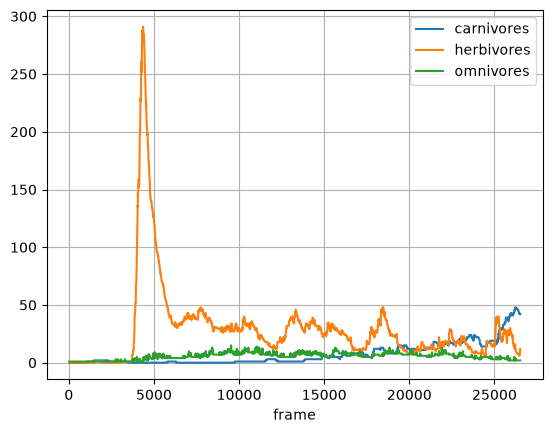

In [21]:
#df["n_plants"].plot()
df["carnivores"].plot()
df["herbivores"].plot()
df["omnivores"].plot()
plt.grid()
plt.legend()